# Imports

In [1]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append('../../')

In [2]:
import glob
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, cross_validate, StratifiedKFold

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin

from tqdm import tqdm
import pickle

from joblib import Parallel, delayed

import numpy as np

In [ ]:
SESSIONS = [
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_20_16_00",
    "M106_2026_02_25_15_00",
    "M106_2026_02_27_16_00",
    # 'M086_2025_12_11_15_00',
    # 'M086_2025_12_10_15_00'
]

# all_sess_proc = {}
for sess in SESSIONS:
    td, _ = dsp.load_and_process_session(sess, std=0.03, bhv_fields=['left_paw','left_wrist'])
    perturb_td = pyal.restrict_to_interval(
        td, start_point_name='idx_sol_on', rel_start=-200, rel_end=300
    )
    perturb_td = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)
    perturb_td    = dsp.drop_trials_sem_crosses_zero(perturb_td, std=True)
    all_sess_proc[sess] = perturb_td


ValueError: No objects to concatenate

M106_2026_02_25_15_00: n=200 (contra only)
M106_2026_02_27_16_00: n=295 (contra only)


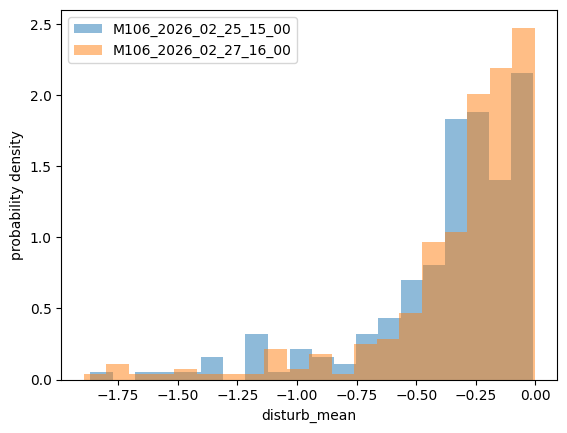

In [53]:
for sess, td in all_sess_proc.items():
    if sess[:4] != 'M106':
        continue
    # td_contra = td[td.sol_contra_ipsi == 1]
    scores = np.stack(td.disturb_score.values)[:, 1]
    print(f'{sess}: n={len(scores)} (contra only)')
    plt.hist(scores, bins=20, alpha=0.5, density=True, label=sess)
plt.xlabel('disturb_mean')
plt.ylabel('probability density')
plt.legend()

# Population dynamics figure

In [3]:
SESSIONS = [
    "M103_2026_02_18_15_30",
    # "M103_2026_02_20_16_00",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_27_16_00",
    # 'M086_2025_12_11_15_00',
    # 'M086_2025_12_10_15_00'
]

all_sess_proc = {}
for sess in SESSIONS:
    td, _ = dsp.load_and_process_session(sess, std=0.03)
    perturb_td = pyal.restrict_to_interval(
        td, start_point_name='idx_sol_on', rel_start=-200, rel_end=300
    )
    perturb_td = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)
    perturb_td    = dsp.drop_trials_sem_crosses_zero(perturb_td, std=True)
    all_sess_proc[sess] = perturb_td


fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
['all_spikes', 'CP_spikes', 'MOp_spikes', 'VAL_spikes', 'SSp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(


Resulting all_spikes ephys data shape is (NxT): (15, 48000)
Resulting CP_spikes ephys data shape is (NxT): (267, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (190, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (126, 48000)
Skipped 8 trials
Otsu immobility threshold: 6.6387
Dropped 70 of 497 rows (14.08%).


/tmp/ipykernel_35682/2188624014.py:13: UserWarning: Dropping 1 trials because of invalid time indexing. For more information, try warn_per_trial=True
  perturb_td = pyal.restrict_to_interval(


  drop_trials_sem_crosses_zero: by SEM: 227  |  by value: 423  |  kept: 226/424 (53.3%)


In [4]:
mop = np.stack(perturb_td.MOp_rates_pca.values)[:, :, :3]

sol_dir=2: n=21 trials
sol_dir=3: n=20 trials


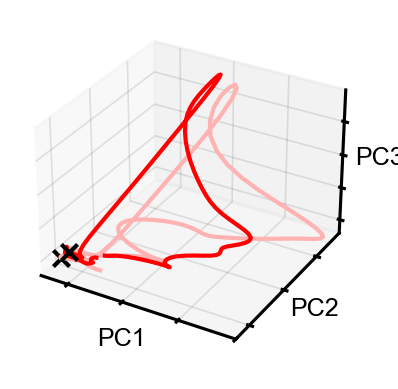

In [23]:
%matplotlib inline
from tools.viz.rc_style import apply_rc_talk
apply_rc_talk()

plot_mask = slice(150, 275)  # timebin range to plot
bl_mask = slice(0, 190)    # baseline window
marker_t = 190               # absolute timebin to mark
grid_alpha = 0.1

cmap = plt.get_cmap('bwr')
sol_dirs = [2, 3]

fig = plt.figure(figsize=(5, 3))
ax = fig.add_subplot(111, projection='3d')
ax.xaxis._axinfo['grid']['color'] = (0, 0, 0, grid_alpha)
ax.yaxis._axinfo['grid']['color'] = (0, 0, 0, grid_alpha)
ax.zaxis._axinfo['grid']['color'] = (0, 0, 0, grid_alpha)

for i, sol_dir in enumerate(sol_dirs):
    mask = perturb_td.values_Sol_direction == sol_dir
    mean_traj = mop[mask.values].mean(axis=0)
    mean_traj = mean_traj - mean_traj[bl_mask].mean(0)
    print(f'sol_dir={sol_dir}: n={mask.sum()} trials')
    traj = mean_traj[plot_mask]
    c = cmap(0.65 + 0.8 * i / (len(sol_dirs) - 1))
    ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], color=c, label=f'dir {sol_dir}')
    mi = marker_t - plot_mask.start
    ax.scatter(*traj[mi], color='black', s=60, zorder=5, depthshade=False, marker='x')

ax.set_xlabel('PC1', labelpad=-10)
ax.set_ylabel('PC2', labelpad=-10)
ax.set_zlabel('PC3', labelpad=-10)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.set_xlim(-10, 60)
# ax.set_ylim(-10, 110)
# ax.set_zlim(-10, 90)
# ax.legend()
fig.savefig('../../results/pdfs/example_traj_dir.svg', bbox_inches='tight')

plt.show()

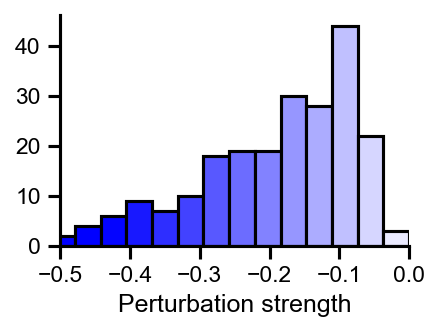

In [25]:
%matplotlib inline
apply_rc_talk()

fig, ax = plt.subplots(figsize=(3, 2))

values = np.stack(perturb_td.disturb_mean.values)
counts, bin_edges_h, patches = ax.hist(values, bins=np.linspace(-0.7, 0, 20), edgecolor='k')

# colour each bar: more negative → darker blue, closer to 0 → lighter blue
cmap = plt.get_cmap('bwr')
cmap_min, cmap_max = 0, 0.5
norm = mpl.colors.Normalize(vmin=bin_edges_h[0]+0.25, vmax=bin_edges_h[-1])
for patch, left in zip(patches, bin_edges_h[:-1]):
    patch.set_facecolor(cmap(cmap_min + (cmap_max - cmap_min) * norm(left)))

ax.set_xlim(-0.5, 0)
ax.set_xlabel('Perturbation strength')
fig.savefig('../../results/pdfs/dist_hist.svg', bbox_inches='tight')

plt.show()

bin 0 (disturb_sum -0.52–0.15): n=76 trials
bin 1 (disturb_sum 0.15–0.43): n=75 trials
bin 2 (disturb_sum 0.43–1.30): n=75 trials


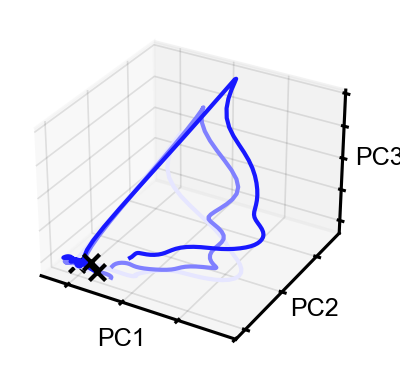

In [21]:
%matplotlib inline
from tools.viz.rc_style import apply_rc_talk
from matplotlib.cm import ScalarMappable
apply_rc_talk()

plot_mask = slice(100, 275)
bl_mask = slice(0, 190)
grid_alpha = 0.1
marker_t = 190

n_bins = 3
disturb_sum = perturb_td.disturb_sum.values
bin_edges = np.percentile(disturb_sum, np.linspace(0, 100, n_bins + 1))
bin_labels = pd.cut(disturb_sum, bins=bin_edges, labels=False, include_lowest=True)

# blue side of bwr: darker = more negative (stronger), lighter = closer to 0 (weaker)
cmap = plt.get_cmap('bwr')
cmap_min, cmap_max = 0.05, 0.45

fig = plt.figure(figsize=(5, 3))
ax = fig.add_subplot(111, projection='3d')
ax.xaxis._axinfo['grid']['color'] = (0, 0, 0, grid_alpha)
ax.yaxis._axinfo['grid']['color'] = (0, 0, 0, grid_alpha)
ax.zaxis._axinfo['grid']['color'] = (0, 0, 0, grid_alpha)

for b in range(n_bins):
    mask = bin_labels == b
    mean_traj = mop[mask].mean(axis=0)
    mean_traj = mean_traj - mean_traj[bl_mask].mean(0)
    lo, hi = bin_edges[b], bin_edges[b + 1]
    print(f'bin {b} (disturb_sum {lo:.2f}–{hi:.2f}): n={mask.sum()} trials')
    traj = mean_traj[plot_mask]
    c = cmap(cmap_max - (cmap_max - cmap_min) * b / (n_bins - 1))
    ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], color=c)
    mi = marker_t - plot_mask.start
    ax.scatter(*traj[mi], color='k', s=60, zorder=5, depthshade=False, marker='x')

ax.set_xlabel('PC1', labelpad=-10)
ax.set_ylabel('PC2', labelpad=-10)
ax.set_zlabel('PC3', labelpad=-10)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
fig.savefig('../../results/pdfs/example_traj_dist.svg', bbox_inches='tight')

plt.show()

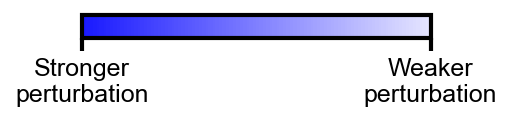

In [11]:
%matplotlib inline
from tools.viz.rc_style import apply_rc_talk
apply_rc_talk()

cmap = plt.get_cmap('bwr')
cmap_min, cmap_max = 0.05, 0.45
colors = cmap(np.linspace(cmap_min, cmap_max, 256))
disturb_cmap = mpl.colors.LinearSegmentedColormap.from_list('disturb_blues', colors)

fig, ax = plt.subplots(figsize=(3, 0.2))
sm = mpl.cm.ScalarMappable(cmap=disturb_cmap, norm=mpl.colors.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, cax=ax, orientation='horizontal')
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Stronger\nperturbation', 'Weaker\nperturbation'])
# cbar.ax.invert_xaxis()
cbar.ax.tick_params(labelsize=12, width=2)
cbar.outline.set_linewidth(2)

plt.show()

n=226 trials
total timebins: 501
perturbation onset marker: PC1=3.717, PC2=0.578, PC3=-0.504


/tmp/ipykernel_35682/1718617189.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_full = mcm.get_cmap('viridis')


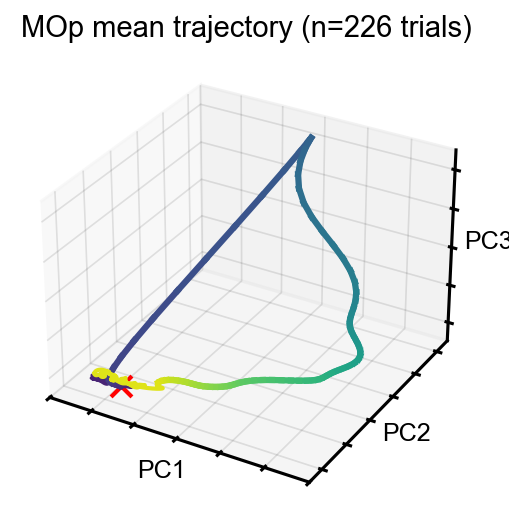

In [ ]:
%matplotlib widget
from tools.viz.rc_style import apply_rc_talk
import matplotlib.cm as mcm
apply_rc_talk()

bl_mask = slice(0, 190)
t_perturb_on  = 190   # perturbation onset (bin index into full traj)
t_perturb_off = 275   # end of perturbation window
t_end         = 500   # end of trajectory
bin_size      = 0.01  # s

mean_traj = mop.mean(axis=0)
mean_traj = mean_traj - mean_traj[bl_mask].mean(0)
print(f"n={len(mop)} trials")
print(f"total timebins: {mean_traj.shape[0]}")

# --- colormap ---
cmap_full = mcm.get_cmap('viridis')
cmap = mpl.colors.LinearSegmentedColormap.from_list('viridis', cmap_full(np.linspace(0.1, 0.95, 256)))

fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot(111, projection='3d')
ax.xaxis._axinfo['grid']['color'] = (0, 0, 0, 0.1)
ax.yaxis._axinfo['grid']['color'] = (0, 0, 0, 0.1)
ax.zaxis._axinfo['grid']['color'] = (0, 0, 0, 0.1)

# 1. Pre-perturbation: solid cmap start color
seg = mean_traj[:t_perturb_on + 1]
ax.plot(seg[:, 0], seg[:, 1], seg[:, 2], color=cmap(0.0), lw=1.5)

# 2. Perturbation window: gradient to show passage of time
n_seg = t_perturb_off - t_perturb_on
for i in range(n_seg):
    t0, t1 = t_perturb_on + i, t_perturb_on + i + 1
    seg = mean_traj[t0:t1 + 1]
    ax.plot(seg[:, 0], seg[:, 1], seg[:, 2], color=cmap(i / n_seg), lw=3)

# 3. Post-perturbation: solid cmap end color
seg = mean_traj[t_perturb_off:t_end + 1]
ax.plot(seg[:, 0], seg[:, 1], seg[:, 2], color=cmap(1.0))

# dot at perturbation onset
ax.scatter(*mean_traj[t_perturb_on], color='r', s=100, zorder=200, marker='x', depthshade=False)
print(f"perturbation onset marker: PC1={mean_traj[t_perturb_on,0]:.3f}, PC2={mean_traj[t_perturb_on,1]:.3f}, PC3={mean_traj[t_perturb_on,2]:.3f}")

ax.set_xlabel('PC1', labelpad=-10)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.set_xlim(-10, 50)
ax.set_ylim(-10, 110)
ax.set_zlim(-10, 90)

ax.set_ylabel('PC2', labelpad=-10)
ax.set_zlabel('PC3', labelpad=-10)
ax.set_title(f'MOp mean trajectory (n={len(mop)} trials)')

# --- composite colorbar as legend ---
# Build a colormap that spans the full time axis:
#   pre  -> solid cmap(0.0)
#   perturb -> gradient
#   post -> solid cmap(1.0)
n_pre   = t_perturb_on
n_perturb = t_perturb_off - t_perturb_on
n_post  = t_end - t_perturb_off

legend_colors = np.vstack([
    np.tile(cmap(0.0), (n_pre, 1)),
    cmap(np.linspace(0.0, 1.0, n_perturb)),
    np.tile(cmap(1.0), (n_post, 1)),
])
legend_cmap = mpl.colors.LinearSegmentedColormap.from_list('traj_legend', legend_colors)

t_start_s = -t_perturb_on * bin_size
t_off_s   =  (t_perturb_off - t_perturb_on) * bin_size
t_end_s   =  (t_end - t_perturb_on) * bin_size

sm = mpl.cm.ScalarMappable(cmap=legend_cmap, norm=mpl.colors.Normalize(vmin=t_start_s, vmax=t_end_s))
sm.set_array([])
# cbar = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.05, location='right')
# cbar.set_ticks([t_start_s, 0.0, t_off_s, t_end_s])
# cbar.set_ticklabels([f'{t_start_s:.1f} s', '0 s', f'{t_off_s:.2f} s', f'{t_end_s:.1f} s'])
# cbar.set_label('time re. perturbation')
fig.savefig('../../results/pdfs/example_traj.pdf', bbox_inches='tight')

plt.show()

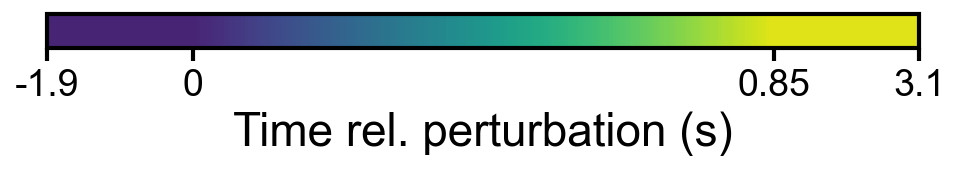

In [19]:
%matplotlib inline

# stretch factor: how many visual units each section gets
n_pre_vis     = 100
n_perturb_vis = 400   # stretched
n_post_vis    = 100
total_vis = n_pre_vis + n_perturb_vis + n_post_vis

# rebuild colormap with stretched perturbation window
legend_colors_h = np.vstack([
    np.tile(cmap(0.0), (n_pre_vis, 1)),
    cmap(np.linspace(0.0, 1.0, n_perturb_vis)),
    np.tile(cmap(1.0), (n_post_vis, 1)),
])
legend_cmap_h = mpl.colors.LinearSegmentedColormap.from_list('traj_legend_h', legend_colors_h)

# tick positions in normalised [0, 1] space
tick_pos = [
    0.0,
    n_pre_vis / total_vis,
    (n_pre_vis + n_perturb_vis) / total_vis,
    1.0,
]
tick_labels = [f'{t_start_s:.1f}', '0', f'{t_off_s:.2f}', f'{t_end_s:.1f}']

fig, ax = plt.subplots(figsize=(7.5, 0.6))
fig.subplots_adjust(bottom=0.5)

sm = mpl.cm.ScalarMappable(cmap=legend_cmap_h, norm=mpl.colors.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, cax=ax, orientation='horizontal')
cbar.set_ticks(tick_pos)
cbar.set_ticklabels(tick_labels)
cbar.ax.tick_params(labelsize=18, width=2)
cbar.outline.set_linewidth(2)
cbar.set_label('Time rel. perturbation (s)', fontsize=22)
fig.savefig('../../results/pdfs/colorbar.svg', bbox_inches='tight')

plt.show()

In [109]:
t_start_s

-1.9000000000000001